In [1]:
import argparse
import torch

from tqdm import tqdm
import pickle

from scipy.stats import mannwhitneyu

In [65]:
all_acts = torch.load("/project/pi_annagreen_umass_edu/bryn/plm_circuit_enrichment/data/summarized_acts_max.pt") #torch.load("data/summarized_acts_top_q.pt")
all_properties = torch.load("metadata/ptn_fam_tensor_nonzero.pt")

print(all_acts.shape)

/tmp/ipykernel_2535129/282129720.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  all_acts = torch.load("/project/pi_annagreen_umass_edu/bryn/plm_circuit_enrichment/data/

torch.Size([10000, 28672])


In [66]:
with open("metadata/list_of_desired_latents.pkl", 'rb') as f:
    subset_list = list(set(pickle.load(f)))
    subset_list.sort()
    

In [67]:
all_acts = all_acts[:,subset_list]

In [68]:

latents_property_pvals = torch.zeros(all_acts.shape[1], all_properties.shape[1])
latents_property_statistic = torch.zeros(all_acts.shape[1], all_properties.shape[1])
latents_property_effect_size = torch.zeros(size=(all_acts.shape[1], all_properties.shape[1],4))

In [69]:
len(subset_list)

383

In [70]:
latents_property_pvals.shape

torch.Size([383, 10096])

In [71]:
all_acts.shape

torch.Size([10000, 383])

In [72]:
all_properties.shape

torch.Size([10000, 10096])

In [73]:
import json

# with open("/work/pi_jensen_umass_edu/jnainani_umass_edu/plm_circuits/results/layer_latent_dicts/layer_latent_dict_2PKEA_0.70.json", "r") as f:
#     pkea_latents = json.load(f)

with open("/work/pi_jensen_umass_edu/jnainani_umass_edu/plm_circuits/results/layer_latent_dicts/layer_latent_dict_MetXA_0.70.json", 'r') as file:
    metx_latents = json.load(file)

with open("/work/pi_jensen_umass_edu/jnainani_umass_edu/plm_circuits/results/layer_latent_dicts/layer_latent_dict_Top2_0.70.json", 'r') as file:
    top2_latents = json.load(file)

In [74]:
offsets = {k: i*4096 for i,k in enumerate(metx_latents.keys())}
full_indices_metx = [j+offsets[layer_id] for layer_id in metx_latents.keys() for j in metx_latents[layer_id]]
full_indices_top2 = [j+offsets[layer_id] for layer_id in top2_latents.keys() for j in top2_latents[layer_id]]
# full_indices_pkea = [j+offsets[layer_id] for layer_id in pkea_latents.keys() for j in pkea_latents[layer_id]]
latent_ids_both_proteins = list(set(full_indices_top2+full_indices_metx))
# latent_ids_both_proteins = list(set(full_indices_pkea))
latent_ids_both_proteins.sort()
len(latent_ids_both_proteins) # yes, only 383 unique

383

In [75]:
subset_list == latent_ids_both_proteins

True

In [76]:
len(latent_ids_both_proteins)

383

In [77]:
def to_flattened_id(layer_id: int, lat_id: int) -> int:
    if layer_id % 4 != 0:
        raise ValueError("layer_id must be a multiple of 4 (e.g., 4, 8, 12, ...)")
    if not (0 <= lat_id < 4096):
        raise ValueError("lat_id must be in [0, 4096)")
    return ((layer_id // 4) - 1) * 4096 + lat_id

In [78]:
test_j = [9339, 8906, 9029]
layer_i = 12
latent_ind = 3035
flattened_id = to_flattened_id(int(layer_i), int(latent_ind))
latent_i = subset_list.index(flattened_id)
print(latent_i)


91


In [79]:
from typing import Sequence, Tuple

def get_layer_and_latent(latent_i: int, flattened_ids: Sequence[int]) -> Tuple[int, int]:
    """
    Given a latent index and a list/array of flattened IDs,
    return (layer_id, latent_ind).

    Assumes:
    - flattened_id -> layer: ((flattened_id // 4096) + 1) * 4
    - flattened_id -> latent_ind: flattened_id % 4096
    """
    if latent_i < 0 or latent_i >= len(flattened_ids):
        raise IndexError("latent_i out of range for flattened_ids")
    cur_flattened = int(flattened_ids[latent_i])
    layer_id = ((cur_flattened // 4096) + 1) * 4
    latent_ind = cur_flattened % 4096
    return layer_id, latent_ind

print(get_layer_and_latent(91, latent_ids_both_proteins))

(12, 3035)


In [80]:
subset_list

[100,
 181,
 237,
 340,
 443,
 495,
 527,
 601,
 794,
 798,
 963,
 1096,
 1196,
 1297,
 1374,
 1468,
 1474,
 1509,
 1682,
 1690,
 1712,
 1807,
 1949,
 2005,
 2112,
 2277,
 2311,
 2340,
 2443,
 2511,
 2850,
 2929,
 2947,
 2983,
 3069,
 3153,
 3170,
 3177,
 3229,
 3326,
 3351,
 3544,
 3612,
 3634,
 3651,
 3701,
 3717,
 3764,
 3788,
 3832,
 4527,
 4584,
 5671,
 6262,
 6582,
 6758,
 6773,
 6871,
 7415,
 7480,
 8017,
 8403,
 8531,
 8757,
 8859,
 8861,
 8990,
 8995,
 9091,
 9096,
 9274,
 9313,
 9396,
 9448,
 9569,
 9606,
 9710,
 9988,
 10010,
 10249,
 10304,
 10342,
 10494,
 10664,
 10666,
 10669,
 10670,
 10704,
 10820,
 10989,
 11037,
 11227,
 11431,
 11690,
 11728,
 11735,
 11749,
 11790,
 11818,
 11943,
 11986,
 12000,
 12041,
 12135,
 12152,
 12211,
 12236,
 12334,
 12445,
 12645,
 12675,
 12679,
 12768,
 12894,
 12919,
 12996,
 13025,
 13088,
 13099,
 13146,
 13216,
 13356,
 13363,
 13454,
 13491,
 13497,
 13524,
 13568,
 13641,
 13668,
 13676,
 13687,
 13735,
 13737,
 13740,
 13748,
 

In [81]:
import pandas as pd
interpro_annotations_nonzero = pd.read_csv("metadata/interpro_entry_list_mapping_nonzero.csv")
interpro_annotations_nonzero.iloc[536]["ENTRY_NAME"]

'Short-chain dehydrogenase/reductase, conserved site'

In [82]:
relevant_interpro_entries = [
    "IPR036291",
    "IPR029063", 
    "IPR036188",
    "IPR029058",
    "IPR002347",
    "IPR046346",
    "IPR023753",
    "IPR020904",
    "IPR006151",
    "IPR004101",
    "IPR013221",
    "IPR000073",
    "IPR040131",
    "IPR002218",
    "IPR015955",
    "IPR001236",
    "IPR022383",
    "IPR001557",
    "IPR020630",
    "IPR020631",
    "IPR000672"
]
relevant_interpro_entries_indices = [i for i, entry in enumerate(interpro_annotations_nonzero['ENTRY_AC']) if entry in relevant_interpro_entries]
relevant_interpro_entries_indices

[536,
 659,
 878,
 1284,
 1489,
 1983,
 2380,
 2381,
 2443,
 2515,
 3086,
 3873,
 4094,
 4267,
 4311,
 8790,
 9059,
 9063,
 9235,
 9278,
 10002]

In [83]:
(interpro_annotations_nonzero['ENTRY_AC'] == 'IPR036291').idxmax()

9278

# tail enrichment

In [31]:
import numpy as np
import pandas as pd
from scipy.stats import fisher_exact, rankdata

# ---- Inputs you already have ----
# all_acts: torch.Tensor or np.ndarray of shape [N_proteins, N_latents]  (top-Q means per protein per latent)
# all_properties: torch.Tensor or np.ndarray of shape [N_proteins, N_domains] (nonzero = has domain)
# latent_i: int (column index in all_acts for the latent of interest, e.g., 56 for L8-2677)
# Optional: relevant_interpro_entries_indices: list[int] subset of columns in all_properties to test

try:
    import torch
except Exception:
    torch = None

def to_numpy(a):
    if torch is not None and isinstance(a, torch.Tensor):
        return a.detach().cpu().numpy()
    return np.asarray(a)

def percentile_ranks(x: np.ndarray) -> np.ndarray:
    """Return percentile ranks in [0,1] with average ranks on ties."""
    # rankdata gives 1..N; convert to 0..1
    r = rankdata(x, method="average")
    return (r - 1) / (x.size - 1) if x.size > 1 else np.zeros_like(r, dtype=float)

def bonferroni(pvals: np.ndarray) -> np.ndarray:
    m = pvals.size
    out = pvals * m
    out[out > 1.0] = 1.0
    return out

def tail_enrichment_table(R: np.ndarray, in_mask: np.ndarray, tau: float = 0.99):
    """
    Build 2x2 counts for Fisher at top tail threshold tau on percentile R.
      a: in-domain & top-tail
      b: out-of-domain & top-tail
      c: in-domain & not top-tail
      d: out-of-domain & not top-tail
    """
    top_mask = R >= np.quantile(R, tau)  # top (1 - tau) fraction; robust to ties
    a = np.sum(in_mask & top_mask)
    b = np.sum(~in_mask & top_mask)
    c = np.sum(in_mask & ~top_mask)
    d = np.sum(~in_mask & ~top_mask)
    return a, b, c, d

# -------------------- MAIN --------------------

def screen_domains_tail_enrichment(
    all_acts,
    all_properties,
    latent_i: int,
    domain_indices: np.ndarray | list | None = None,
    tau: float = 0.99,
    n_in_min: int = 20,
    n_out_min: int = 200,
    use_bonferroni: bool = True,
    return_tau_all_in: bool = True,  # NEW
    coverage_fracs: tuple[float, ...] | None = (0.95, 0.90),  # NEW
):
    X = to_numpy(all_acts)
    D = to_numpy(all_properties)

    assert X.ndim == 2, "all_acts must be 2D [N, L]"
    assert D.ndim == 2, "all_properties must be 2D [N, M]"
    N = X.shape[0]

    # 1) Percentile ranks (scale-agnostic) for the chosen latent
    R = percentile_ranks(X[:, latent_i])

    # Domain set to consider
    if domain_indices is None:
        domain_indices = np.arange(D.shape[1])
    else:
        domain_indices = np.asarray(domain_indices, dtype=int)

    # Binarize domain membership (nonzero -> True)
    D_bin = D[:, domain_indices] != 0

    # Precompute the top-mask once (so Fisher thresholds are consistent across domains)
    # This uses same tau for every domain.
    thr = np.quantile(R, tau)
    top_mask = R >= thr
    not_top_mask = ~top_mask

    # Precompute totals
    top_count = int(top_mask.sum())
    not_top_count = N - top_count

    # Counts per domain (vectorized where possible)
    in_counts = D_bin.sum(axis=0)                    # n_in per domain
    out_counts = N - in_counts                       # n_out per domain

    # Filter domains by minimum sizes
    ok = (in_counts >= n_in_min) & (out_counts >= n_out_min)
    idxs = domain_indices[ok]
    if idxs.size == 0:
        cols = [
            "domain_idx", "n_in", "n_out",
            "a_top_in", "b_top_out", "c_not_top_in", "d_not_top_out",
            "odds_ratio", "fisher_p", "p_adj",
            "median_pos_percentile"
        ]
        if return_tau_all_in:
            cols.append("tau_all_in")
        return pd.DataFrame(columns=cols)

    D_ok = D_bin[:, ok]  # [N, K]
    n_in = in_counts[ok]
    n_out = out_counts[ok]

    # Vectorized a, c via matrix multiplications / sums
    a_vec = (top_mask[:, None] & D_ok).sum(axis=0)        # top & in
    c_vec = (not_top_mask[:, None] & D_ok).sum(axis=0)    # not top & in
    b_vec = top_count - a_vec                              # top & out
    d_vec = not_top_count - c_vec                          # not top & out

    # Fisher p-values and OR (loop per domain; fast enough for ~10k)
    pvals = np.empty(a_vec.size, dtype=float)
    ORs = np.empty(a_vec.size, dtype=float)
    for k in range(a_vec.size):
        a, b, c, d = int(a_vec[k]), int(b_vec[k]), int(c_vec[k]), int(d_vec[k])
        # Add a tiny continuity guard if any cell is zero when computing OR
        if a == 0 or b == 0 or c == 0 or d == 0:
            OR = ((a + 0.5) / (c + 0.5)) / ((b + 0.5) / (d + 0.5))
        else:
            OR = (a / c) / (b / d)
        ORs[k] = OR
        _, p = fisher_exact([[a, b], [c, d]], alternative="greater")
        pvals[k] = p

    p_adj = bonferroni(pvals) if use_bonferroni else pvals  # plug-in BH here if you later switch

    # Median positive percentile per domain
    med_pos = np.empty(a_vec.size, dtype=float)
    for k in range(a_vec.size):
        mask_k = D_ok[:, k]
        r_in = R[mask_k]
        med_pos[k] = float(np.median(r_in)) if r_in.size > 0 else np.nan

    data = {
        "domain_idx": idxs,
        "domain_name": [interpro_annotations_nonzero.iloc[idx]["ENTRY_NAME"] for idx in idxs],
        "n_in": n_in.astype(int),
        "n_out": n_out.astype(int),
        "a_top_in": a_vec.astype(int),
        "b_top_out": b_vec.astype(int),
        "c_not_top_in": c_vec.astype(int),
        "d_not_top_out": d_vec.astype(int),
        "odds_ratio": ORs,
        "fisher_p": pvals,
        "p_adj": p_adj,
        "median_pos_percentile": med_pos,
    }
        # NEW: tau at which ≥p of in-domain are in the top tail (p in coverage_fracs)
    if coverage_fracs:
        coverage_fracs = tuple(sorted(coverage_fracs, reverse=True))  # e.g., (0.95, 0.90)
        sorted_R = np.sort(R)
        denom = max(N - 1, 1)

        # Collect per-domain lower-tail quantiles r_q for q = 1 - p
        r_q = {p: np.empty(a_vec.size, dtype=float) for p in coverage_fracs}

        for k in range(a_vec.size):
            mask_k = D_ok[:, k]
            r_in = R[mask_k]
            if r_in.size == 0:
                for p in coverage_fracs:
                    r_q[p][k] = np.nan
            else:
                for p in coverage_fracs:
                    q = 1.0 - p  # need thr <= q-quantile to cover ≥p of in-domain
                    r_q[p][k] = float(np.quantile(r_in, q))

        for p in coverage_fracs:
            idx = np.searchsorted(sorted_R, r_q[p], side="right") - 1
            tau_cover = np.clip(idx / denom, 0.0, 1.0)
            data[f"tau_cover_{int(p*100)}"] = tau_cover

    # NEW: per-domain largest tau such that c == 0 (all in-domain are in top tail)
    if return_tau_all_in:
        sorted_R = np.sort(R)  # ascending
        # per-domain minimum in-domain percentile
        r_min_in = np.where(D_ok, R[:, None], np.inf).min(axis=0)
        # last index in sorted_R where value <= r_min_in
        last_le_idx = np.searchsorted(sorted_R, r_min_in, side="right") - 1
        # convert to tau using numpy's default quantile definition (linear over indices 0..N-1)
        denom = max(N - 1, 1)
        tau_all_in = np.clip(last_le_idx / denom, 0.0, 1.0)
        data["tau_all_in"] = tau_all_in

    df = pd.DataFrame(data)

    # Suggested default ranking: strongest practical signals first
    df = df.sort_values(
        by=["p_adj", "odds_ratio", "median_pos_percentile"],
        ascending=[True, False, False]
    ).reset_index(drop=True)

    return df

In [59]:
layer_i = 8
latent_ind = 488
flattened_id = to_flattened_id(int(layer_i), int(latent_ind))
latent_i = subset_list.index(flattened_id)
# ---- Example call (adjust tau / mins if you like) ----
df_hits = screen_domains_tail_enrichment(
    all_acts=all_acts,
    all_properties=all_properties,
    latent_i=latent_i,                # e.g., 56 for your L8-2677 in subset_list
    domain_indices=None, # relevant_interpro_entries_indices,
    tau=0.90,                         # top 1%
    n_in_min=10,
    n_out_min=200,
    use_bonferroni=True,
    return_tau_all_in=True,
    coverage_fracs=(0.95, 0.90)
)
# df_hits.head(25)
# To call hits:
hits = df_hits[(df_hits["p_adj"] <= 0.05) & (df_hits["odds_ratio"] >= 5)]
hits.head(25)


,domain_idx,domain_name,n_in,n_out,a_top_in,b_top_out,c_not_top_in,d_not_top_out,odds_ratio,fisher_p,p_adj,median_pos_percentile,tau_cover_95,tau_cover_90,tau_all_in


In [27]:
df_hits = screen_domains_tail_enrichment(
    all_acts=all_acts,
    all_properties=all_properties,
    latent_i=latent_i,                # e.g., 56 for your L8-2677 in subset_list
    domain_indices=None, # relevant_interpro_entries_indices,
    tau=0.98,                         # top 1%
    n_in_min=10,
    n_out_min=200,
    use_bonferroni=True,
    return_tau_all_in=True,
    coverage_fracs=(0.95, 0.90)
)
# df_hits.head(25)
# To call hits:
hits = df_hits[(df_hits["p_adj"] <= 0.05) & (df_hits["odds_ratio"] >= 5)]
hits.head(25)

,domain_idx,domain_name,n_in,n_out,a_top_in,b_top_out,c_not_top_in,d_not_top_out,odds_ratio,fisher_p,p_adj,median_pos_percentile,tau_cover_95,tau_cover_90,tau_all_in
0,9059,Alpha/Beta hydrolase fold,63,9937,48,152,15,9785,206.000000,6.558475e-71,7.922638e-68,0.996900,0.971197,0.975298,0.964996
1,659,Alpha/beta hydrolase fold-1,16,9984,16,184,0,9800,1752.934959,3.581893e-28,4.326926e-25,0.998000,0.993799,0.995900,0.987599
2,4162,Small GTPase,16,9984,12,188,4,9796,156.319149,4.996955e-18,6.036321e-15,0.990549,0.964996,0.964996,0.964996
3,1395,Small GTP-binding domain,128,9872,23,177,105,9695,11.998117,5.230340e-16,6.318250e-13,0.482498,0.964996,0.964996,0.964996
4,204,"DNA methylase, N-6 adenine-specific, conserved...",13,9987,7,193,6,9794,59.203800,1.787085e-09,2.158798e-06,0.983198,0.964996,0.968997,0.964996
5,2717,EngB-type guanine nucleotide-binding (G) domain,11,9989,6,194,5,9795,60.587629,2.524551e-08,3.049658e-05,0.985999,0.964996,0.964996,0.964996
6,6266,"GTP-binding protein, ribosome biogenesis, YsxC",11,9989,6,194,5,9795,60.587629,2.524551e-08,3.049658e-05,0.985999,0.964996,0.964996,0.964996
7,1458,GTP binding domain,62,9938,10,190,52,9748,9.866397,3.557855e-07,4.297889e-04,0.482498,0.964996,0.964996,0.964996
8,9063,S-adenosyl-L-methionine-dependent methyltransf...,179,9821,16,184,163,9637,5.141104,5.469434e-07,6.607076e-04,0.482498,0.964996,0.964996,0.964996
9,4213,Phosphopantetheine adenylyltransferase,18,9982,6,194,12,9788,25.226804,9.022296e-07,1.089893e-03,0.482498,0.964996,0.964996,0.964996


In [30]:
df_hits = screen_domains_tail_enrichment(
    all_acts=all_acts,
    all_properties=all_properties,
    latent_i=latent_i,                # e.g., 56 for your L8-2677 in subset_list
    domain_indices=None, # relevant_interpro_entries_indices,
    tau=0.95,                         # top 1%
    n_in_min=10,
    n_out_min=200,
    use_bonferroni=True,
    return_tau_all_in=True,
    coverage_fracs=(0.95, 0.90)
)
df_hits.head(25)
# To call hits:
# hits = df_hits[(df_hits["p_adj"] <= 0.05) & (df_hits["odds_ratio"] >= 5)]
# hits.head(25)

,domain_idx,domain_name,n_in,n_out,a_top_in,b_top_out,c_not_top_in,d_not_top_out,odds_ratio,fisher_p,p_adj,median_pos_percentile,tau_cover_95,tau_cover_90,tau_all_in
0,9005,P-loop containing nucleoside triphosphate hydr...,652,9348,652,9348,0,0,0.069797,1.0,1.0,0.482498,0.964996,0.964996,0.964996
1,8760,Rossmann-like alpha/beta/alpha sandwich fold,261,9739,261,9739,0,0,0.026849,1.0,1.0,0.482498,0.964996,0.964996,0.964996
2,8740,Aldolase-type TIM barrel,245,9755,245,9755,0,0,0.025165,1.0,1.0,0.482498,0.964996,0.964996,0.964996
3,8707,"Nucleic acid-binding, OB-fold",235,9765,235,9765,0,0,0.024116,1.0,1.0,0.482498,0.964996,0.964996,0.964996
4,9278,NAD(P)-binding domain superfamily,206,9794,206,9794,0,0,0.021083,1.0,1.0,0.482498,0.964996,0.964996,0.964996
5,9063,S-adenosyl-L-methionine-dependent methyltransf...,179,9821,179,9821,0,0,0.018276,1.0,1.0,0.482498,0.964996,0.964996,0.964996
6,1206,AAA+ ATPase domain,175,9825,175,9825,0,0,0.017862,1.0,1.0,0.482498,0.964996,0.964996,0.964996
7,9320,Winged helix-like DNA-binding domain superfamily,138,9862,138,9862,0,0,0.014043,1.0,1.0,0.482498,0.964996,0.964996,0.964996
8,8865,Ribosomal protein uS5 domain 2-type superfamily,136,9864,136,9864,0,0,0.013837,1.0,1.0,0.482498,0.964996,0.964996,0.964996
9,1395,Small GTP-binding domain,128,9872,128,9872,0,0,0.013016,1.0,1.0,0.482498,0.964996,0.964996,0.964996


In [84]:
all_acts[:, 100]

tensor([2.5645, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.9976])

In [85]:
latent_specs = [
    (4, 798),
    (12, 2112),
    (8, 2677),
    # (12, 3035),
    # (8, 488),
    # (12, 1256),
    # (12, 3794),
    # (12, 3536),
    # (12, 2797),
    # (16, 1166),
    # (8, 2775),
    # (8, 2166),
    # (12, 2472),
    # (12, 1082),
    # add more (layer_i, latent_ind) tuples here
]

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Assumes you already defined:
# - latent_specs: list[(layer_i, latent_ind)]
# - to_flattened_id, subset_list
# - all_acts (N x L matrix of activations)

out_dir = Path("../results/act_sorted_max/")
out_dir.mkdir(parents=True, exist_ok=True)

def save_activation_curve(layer_i, latent_ind, tau=0.99, symlog=False, out_dir=out_dir):
    flattened_id = to_flattened_id(int(layer_i), int(latent_ind))
    latent_i = subset_list.index(flattened_id)

    v = to_numpy(all_acts)[:, latent_i].astype(float)
    order = np.argsort(v)[::-1]
    s = v[order]
    N = s.size

    k_top = max(1, int(np.ceil((1 - tau) * N)))

    if N > 1 and (s.max() - s.min()) > 0:
        x = np.linspace(0.0, 1.0, N)
        y = (s - s.min()) / (s.max() - s.min() + 1e-12)
        line = 1.0 - x
        knee_idx = int(np.argmax(y - line))
    else:
        knee_idx = 0

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(np.arange(1, N + 1), s, lw=1.2)
    ax.axvline(k_top, color="crimson", ls="--", alpha=0.7, label=f"top {100*(1-tau):.1f}%")
    ax.axvline(knee_idx + 1, color="teal", ls=":", alpha=0.7, label="knee")
    ax.set_xlabel("Proteins (sorted by latent activation, rank)")
    ax.set_ylabel("Activation")
    ax.set_xlim(1, N)
    if symlog:
        ax.set_yscale("symlog")
    ax.legend(frameon=False)
    ax.set_title(f"L{layer_i}-{latent_ind} (flat {flattened_id})")
    plt.tight_layout()

    out_path = out_dir / f"L{layer_i}_{latent_ind}_sorted_curve.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {out_path.resolve()}")

# Run for all specified latents
for layer_i, latent_ind in latent_specs:
    save_activation_curve(layer_i, latent_ind, tau=0.99, symlog=False)

Saved: /work/pi_jensen_umass_edu/jnainani_umass_edu/plm_circuits/notebooks/results/act_sorted_max/L4_798_sorted_curve.png
Saved: /work/pi_jensen_umass_edu/jnainani_umass_edu/plm_circuits/notebooks/results/act_sorted_max/L12_2112_sorted_curve.png
Saved: /work/pi_jensen_umass_edu/jnainani_umass_edu/plm_circuits/notebooks/results/act_sorted_max/L8_2677_sorted_curve.png


In [86]:
for index in range(len(subset_list)):
    layer_id, latent_ind = get_layer_and_latent(index, subset_list)
    # print(layer_id, latent_ind)
    save_activation_curve(layer_id, latent_ind, tau=0.99, symlog=False, out_dir=Path("../results/act_sorted_max/"))

Saved: /work/pi_jensen_umass_edu/jnainani_umass_edu/plm_circuits/notebooks/results/act_sorted_max/L4_100_sorted_curve.png
Saved: /work/pi_jensen_umass_edu/jnainani_umass_edu/plm_circuits/notebooks/results/act_sorted_max/L4_181_sorted_curve.png
Saved: /work/pi_jensen_umass_edu/jnainani_umass_edu/plm_circuits/notebooks/results/act_sorted_max/L4_237_sorted_curve.png
Saved: /work/pi_jensen_umass_edu/jnainani_umass_edu/plm_circuits/notebooks/results/act_sorted_max/L4_340_sorted_curve.png
Saved: /work/pi_jensen_umass_edu/jnainani_umass_edu/plm_circuits/notebooks/results/act_sorted_max/L4_443_sorted_curve.png
Saved: /work/pi_jensen_umass_edu/jnainani_umass_edu/plm_circuits/notebooks/results/act_sorted_max/L4_495_sorted_curve.png
Saved: /work/pi_jensen_umass_edu/jnainani_umass_edu/plm_circuits/notebooks/results/act_sorted_max/L4_527_sorted_curve.png
Saved: /work/pi_jensen_umass_edu/jnainani_umass_edu/plm_circuits/notebooks/results/act_sorted_max/L4_601_sorted_curve.png
Saved: /work/pi_jensen_u

In [87]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Absolute paths (as requested)
base_dir = Path("/work/pi_jensen_umass_edu/jnainani_umass_edu/plm_circuits/notebooks/results")
dirs = {
    "mean": base_dir / "act_sorted_mean",
    "max": base_dir / "act_sorted_max",
    "topq": base_dir / "act_sorted_topq",
}
out_dir = base_dir / "act_sorted_combined"
out_dir.mkdir(parents=True, exist_ok=True)

order = ("mean", "max", "topq")  # left-to-right

# Collect common basenames present in all three metric dirs
name_sets = []
for m in order:
    name_sets.append({p.name for p in dirs[m].glob("L*_sorted_curve.png")})
common = set.intersection(*name_sets) if name_sets else set()

def combine_triptych(basename, order=order):
    imgs = []
    for metric in order:
        img_path = dirs[metric] / basename
        if not img_path.exists():
            return False
        imgs.append(mpimg.imread(img_path))

    # Create figure sized similar to originals: each original ~8x4, so width scales with count
    fig, axes = plt.subplots(1, len(order), figsize=(8 * len(order), 4))
    if len(order) == 1:
        axes = [axes]

    for ax, metric, im in zip(axes, order, imgs):
        ax.imshow(im)
        ax.set_title(metric)
        ax.axis("off")

    fig.suptitle(basename.replace("_sorted_curve.png", ""), y=0.98)
    plt.tight_layout()
    out_path = out_dir / basename.replace("_sorted_curve.png", "_combined.png")
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {out_path}")
    return True

count = 0
for basename in sorted(common):
    ok = combine_triptych(basename, order=order)
    if ok:
        count += 1

print(f"Combined {count} images into: {out_dir}")

Saved: /work/pi_jensen_umass_edu/jnainani_umass_edu/plm_circuits/notebooks/results/act_sorted_combined/L12_1082_combined.png
Saved: /work/pi_jensen_umass_edu/jnainani_umass_edu/plm_circuits/notebooks/results/act_sorted_combined/L12_1121_combined.png
Saved: /work/pi_jensen_umass_edu/jnainani_umass_edu/plm_circuits/notebooks/results/act_sorted_combined/L12_1204_combined.png
Saved: /work/pi_jensen_umass_edu/jnainani_umass_edu/plm_circuits/notebooks/results/act_sorted_combined/L12_1256_combined.png
Saved: /work/pi_jensen_umass_edu/jnainani_umass_edu/plm_circuits/notebooks/results/act_sorted_combined/L12_1377_combined.png
Saved: /work/pi_jensen_umass_edu/jnainani_umass_edu/plm_circuits/notebooks/results/act_sorted_combined/L12_1414_combined.png
Saved: /work/pi_jensen_umass_edu/jnainani_umass_edu/plm_circuits/notebooks/results/act_sorted_combined/L12_1518_combined.png
Saved: /work/pi_jensen_umass_edu/jnainani_umass_edu/plm_circuits/notebooks/results/act_sorted_combined/L12_1796_combined.png


In [ ]:
!pip install ruptures

In [ ]:
# pip install ruptures scikit-learn  # if needed

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import ruptures as rpt
from sklearn.mixture import GaussianMixture

out_dir = Path("../results/act_hist")
out_dir.mkdir(parents=True, exist_ok=True)

def gmm_intersections(means, stds, weights):
    # compute intersections between neighboring Gaussians (in value space)
    # returns list of t values where w1*N1(t) == w2*N2(t)
    order = np.argsort(means)
    mu = means[order]
    sd = stds[order]
    w = weights[order]
    ts = []
    for i in range(len(mu)-1):
        m1, s1, w1 = mu[i], sd[i], w[i]
        m2, s2, w2 = mu[i+1], sd[i+1], w[i+1]
        # Solve: log(w1/s1) - (t-m1)^2/(2 s1^2) = log(w2/s2) - (t-m2)^2/(2 s2^2)
        A = 1/(2*s2**2) - 1/(2*s1**2)
        B = m1/(s1**2) - m2/(s2**2)
        C = (m2**2)/(2*s2**2) - (m1**2)/(2*s1**2) + np.log((w2/s2)/(w1/s1) + 1e-12)
        if abs(A) < 1e-12:  # nearly equal variances -> linear
            t = -C / (B + 1e-12)
            ts.append(t)
        else:
            disc = B*B - 4*A*C
            if disc >= 0:
                t1 = (-B + np.sqrt(disc)) / (2*A)
                t2 = (-B - np.sqrt(disc)) / (2*A)
                # pick intersection between the two means if possible
                cand = [t for t in (t1, t2) if min(m1, m2) <= t <= max(m1, m2)]
                ts.append(cand[0] if cand else np.median([t1, t2]))
    return ts

def gmm_cutpoints(values, K_max=3):
    X = np.asarray(values, dtype=float).reshape(-1, 1)
    best = None
    best_bic = np.inf
    for k in range(1, K_max+1):
        gm = GaussianMixture(n_components=k, covariance_type="full", random_state=0)
        gm.fit(X)
        bic = gm.bic(X)
        if bic < best_bic:
            best_bic, best = bic, gm
    if best.n_components == 1:
        return [], best  # unimodal; no cutpoint
    ts = gmm_intersections(best.means_.ravel(), np.sqrt(best.covariances_.ravel()), best.weights_.ravel())
    return sorted(ts), best

def changepoint_knees(sorted_values, model="rbf", pen=5.0, max_bkps=5):
    y = np.asarray(sorted_values, dtype=float)
    algo = rpt.Pelt(model=model).fit(y)
    bkp = algo.predict(pen=pen)  # includes N at the end
    idxs = sorted(set([i for i in bkp if 1 <= i < len(y)]))
    if max_bkps is not None:
        idxs = idxs[:max_bkps]
    return idxs  # indices in 1..N-1 (right boundary of segment)

def save_activation_curve_with_knees(layer_i, latent_ind, tau=0.99, pen=5.0, K_max=3, symlog=False):
    flattened_id = to_flattened_id(int(layer_i), int(latent_ind))
    latent_i = subset_list.index(flattened_id)

    v = to_numpy(all_acts)[:, latent_i].astype(float)
    order = np.argsort(v)[::-1]
    s = v[order]
    N = s.size

    # top-% marker
    k_top = max(1, int(np.ceil((1 - tau) * N)))

    # change-point knees (multiple)
    cp_idxs = changepoint_knees(s, model="rbf", pen=pen, max_bkps=5)

    # GMM cutpoints in value space -> convert to rank indices on sorted-desc s
    cut_vals, gm = gmm_cutpoints(v, K_max=K_max)
    cut_ranks = [int(np.count_nonzero(s >= t)) for t in cut_vals]  # 1-based positions

    # plot
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(np.arange(1, N + 1), s, lw=1.2, color="black")
    ax.axvline(k_top, color="crimson", ls="--", alpha=0.7, label=f"top {100*(1-tau):.1f}%")

    for k in cp_idxs:
        ax.axvline(k, color="teal", ls=":", alpha=0.8)
    if cp_idxs:
        ax.plot([], [], color="teal", ls=":", label=f"change-points ({len(cp_idxs)})")

    for k in cut_ranks:
        ax.axvline(k, color="purple", ls="-.", alpha=0.7)
    if cut_ranks:
        ax.plot([], [], color="purple", ls="-.", label=f"GMM cuts ({len(cut_ranks)})")

    ax.set_xlabel("Proteins (sorted by latent activation, rank)")
    ax.set_ylabel("Activation")
    if symlog:
        ax.set_yscale("symlog")
    ax.set_xlim(1, N)
    ax.set_title(f"L{layer_i}-{latent_ind} (flat {flattened_id})")
    ax.legend(frameon=False)
    plt.tight_layout()

    out_path = out_dir / f"L{layer_i}_{latent_ind}_knees.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {out_path.resolve()}")

# Run for all latents
for layer_i, latent_ind in latent_specs:
    save_activation_curve_with_knees(layer_i, latent_ind, tau=0.99, pen=5.0, K_max=3, symlog=False)

In [ ]:
# pip install ruptures scikit-learn  # if needed

import time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

try:
    import torch
except Exception:
    torch = None

# Optional, for curvature method (very fast) and nice peak picking
try:
    from scipy.signal import savgol_filter, find_peaks
    _HAVE_SIGNAL = True
except Exception:
    _HAVE_SIGNAL = False

# Optional, change-point detection (fast with model='l2')
try:
    import ruptures as rpt
    _HAVE_RUPTURES = True
except Exception:
    _HAVE_RUPTURES = False

# Optional, mixture modeling
try:
    from sklearn.mixture import GaussianMixture
    _HAVE_SK = True
except Exception:
    _HAVE_SK = False

out_dir = Path("../results/act_hist")
out_dir.mkdir(parents=True, exist_ok=True)

def get_latent_vector(all_acts, latent_i):
    # Avoid copying the full matrix; move only the column
    if torch is not None and isinstance(all_acts, torch.Tensor):
        return all_acts[:, latent_i].detach().cpu().numpy().astype(float)
    arr = np.asarray(all_acts)
    return arr[:, latent_i].astype(float)

def curvature_knees(sorted_values, max_peaks=5, smooth_win=101, poly=3, min_prom=0.01):
    y = np.asarray(sorted_values, dtype=float)
    N = y.size
    if N < 5:
        return []
    # Normalize to [0,1] for stable curvature
    y = (y - y.min()) / (y.max() - y.min() + 1e-12)
    if _HAVE_SIGNAL:
        win = min(smooth_win, N - (1 - N % 2))  # ensure odd and <= N-1
        if win % 2 == 0: win -= 1
        if win < 5: win = 5
        y_s = savgol_filter(y, window_length=win, polyorder=min(poly, max(1, win-2)))
    else:
        # Lightweight moving average fallback
        k = max(5, min(101, N // 100))
        y_s = np.convolve(y, np.ones(k)/k, mode="same")
    dy = np.gradient(y_s)
    ddy = np.gradient(dy)
    curv = np.abs(ddy)
    if _HAVE_SIGNAL:
        peaks, props = find_peaks(curv, prominence=min_prom)
        # rank by prominence, take top
        if peaks.size:
            order = np.argsort(props["prominence"])[::-1][:max_peaks]
            return sorted((int(peaks[i]) + 1 for i in order))  # to 1-based rank positions
        return []
    else:
        # Take top-k curvature points, spaced apart
        idxs = np.argsort(curv)[::-1]
        sel = []
        min_spacing = max(10, N // 200)
        for i in idxs:
            if not sel or all(abs(i - j) >= min_spacing for j in sel):
                sel.append(i)
            if len(sel) >= max_peaks:
                break
        return sorted((int(i) + 1 for i in sel))

def changepoint_knees_fast(sorted_values, model="l2", pen=10.0, max_bkps=5, target_points=20000):
    if not _HAVE_RUPTURES:
        return []
    y = np.asarray(sorted_values, dtype=float)
    N = y.size
    if N <= 2:
        return []
    # Downsample for speed if very long
    stride = max(1, N // target_points)
    y_ds = y[::stride]
    algo = rpt.Pelt(model=model).fit(y_ds)
    bkp = algo.predict(pen=pen)  # includes len(y_ds)
    idxs_ds = [i for i in bkp if 1 <= i < len(y_ds)]
    if max_bkps is not None:
        idxs_ds = idxs_ds[:max_bkps]
    # Map back to original indices (1-based rank positions)
    idxs = [min(N, max(1, i * stride)) for i in idxs_ds]
    return sorted(set(idxs))

def gmm_cutpoints_fast(values, K_max=3, max_fit_n=200000, random_state=0):
    if not _HAVE_SK:
        return []
    X_full = np.asarray(values, dtype=float).reshape(-1, 1)
    N = X_full.shape[0]
    if N > max_fit_n:
        sel = np.random.default_rng(random_state).choice(N, size=max_fit_n, replace=False)
        X = X_full[sel]
    else:
        X = X_full
    best, best_bic = None, np.inf
    for k in range(1, K_max + 1):
        gm = GaussianMixture(n_components=k, covariance_type="diag", random_state=random_state)
        gm.fit(X)
        bic = gm.bic(X)
        if bic < best_bic:
            best_bic, best = bic, gm
    if best.n_components == 1:
        return []
    means = best.means_.ravel()
    stds = np.sqrt(best.covariances_.ravel())
    weights = best.weights_.ravel()

    # Intersections between adjacent Gaussians (1D closed-form)
    order = np.argsort(means)
    mu, sd, w = means[order], stds[order], weights[order]
    ts = []
    for i in range(len(mu)-1):
        m1, s1, w1 = mu[i], sd[i], w[i]
        m2, s2, w2 = mu[i+1], sd[i+1], w[i+1]
        A = 1/(2*s2**2) - 1/(2*s1**2)
        B = m1/(s1**2) - m2/(s2**2)
        C = (m2**2)/(2*s2**2) - (m1**2)/(2*s1**2) + np.log((w2/s2)/(w1/s1) + 1e-12)
        if abs(A) < 1e-12:
            t = -C / (B + 1e-12)
            ts.append(t)
        else:
            disc = B*B - 4*A*C
            if disc >= 0:
                t1 = (-B + np.sqrt(disc)) / (2*A)
                t2 = (-B - np.sqrt(disc)) / (2*A)
                cand = [t for t in (t1, t2) if min(m1, m2) <= t <= max(m1, m2)]
                ts.append(cand[0] if cand else np.median([t1, t2]))
    return sorted(ts)

def save_activation_curve_with_knees_fast(layer_i, latent_ind,
                                          tau=0.99,
                                          use_cp=True, cp_model="l2", cp_pen=10.0, cp_max=5,
                                          use_gmm=True, gmm_Kmax=3,
                                          use_curv=True, curv_max=5,
                                          symlog=False, verbose=True):
    import time
    t0 = time.perf_counter()
    flattened_id = to_flattened_id(int(layer_i), int(latent_ind))
    latent_i = subset_list.index(flattened_id)

    v = get_latent_vector(all_acts, latent_i)
    t1 = time.perf_counter()
    if verbose:
        print(f"L{layer_i}-{latent_ind}: N={v.size} | fetch_col={t1 - t0:.3f}s")

    order = np.argsort(v)[::-1]
    s = v[order]
    N = s.size
    k_top = max(1, int(np.ceil((1 - tau) * N)))

    # ---- thresholds (indices are 1-based rank positions) ----
    cp_idxs = changepoint_knees_fast(s, model=cp_model, pen=cp_pen, max_bkps=cp_max, target_points=20000) if use_cp else []
    cut_vals = gmm_cutpoints_fast(v, K_max=gmm_Kmax) if use_gmm else []
    cut_ranks = [int(np.count_nonzero(s >= t)) for t in cut_vals]
    curv_idxs = curvature_knees(s, max_peaks=curv_max) if use_curv else []

    # ---- area ratios: top-k sum divided by total sum ----
    s_for_area = s.copy()
    if s_for_area.sum() <= 0:
        shift = -s_for_area.min()
        s_for_area = s_for_area + shift  # ensure nonnegative area baseline
        if verbose:
            print(f"  note: shifted activations by {shift:.3g} for nonnegative area")

    cum = np.cumsum(s_for_area)
    total = float(cum[-1]) + 1e-12
    def area_ratio(k):
        k = int(np.clip(k, 1, N))
        return float(cum[k-1]) / total

    ratio_tau = area_ratio(k_top)
    ratios_cp = [(k, area_ratio(k), k / N) for k in cp_idxs]
    ratios_gmm = [(k, area_ratio(k), k / N) for k in cut_ranks]
    ratios_curv = [(k, area_ratio(k), k / N) for k in curv_idxs]

    if verbose:
        print(f"  tau={tau:.3f} -> k_top={k_top} ({k_top/N:.3%}) | area_ratio={ratio_tau:.4f}")
        if ratios_cp:
            print("  CP area ratios:", ", ".join([f"k={k} ({frac:.1%}) r={r:.4f}" for k,r,frac in ratios_cp]))
        if ratios_gmm:
            print("  GMM area ratios:", ", ".join([f"k={k} ({frac:.1%}) r={r:.4f}" for k,r,frac in ratios_gmm]))
        if ratios_curv:
            print("  Curv area ratios:", ", ".join([f"k={k} ({frac:.1%}) r={r:.4f}" for k,r,frac in ratios_curv]))

    # ---- plot ----
    fig, ax = plt.subplots(figsize=(8, 4))
    x = np.arange(1, N + 1)
    ax.plot(x, s, lw=1.2, color="black")
    # shade tau top-k area
    ax.fill_between(x[:k_top], s[:k_top], 0, color="crimson", alpha=0.15, step=None)
    ax.axvline(k_top, color="crimson", ls="--", alpha=0.8, label=f"top {100*(1-tau):.1f}% (area {ratio_tau:.2f})")

    for k in cp_idxs:
        ax.axvline(k, color="teal", ls=":", alpha=0.8)
    if cp_idxs:
        # show average area ratio for brevity
        avg_cp = np.mean([r for _, r, _ in ratios_cp]) if ratios_cp else 0.0
        ax.plot([], [], color="teal", ls=":", label=f"change-points ({len(cp_idxs)}; avg area {avg_cp:.2f})")

    for k in cut_ranks:
        ax.axvline(k, color="purple", ls="-.", alpha=0.7)
    if cut_ranks:
        avg_gmm = np.mean([r for _, r, _ in ratios_gmm]) if ratios_gmm else 0.0
        ax.plot([], [], color="purple", ls="-.", label=f"GMM cuts ({len(cut_ranks)}; avg area {avg_gmm:.2f})")

    for k in curv_idxs:
        ax.axvline(k, color="orange", ls="--", alpha=0.7)
    if curv_idxs:
        avg_cv = np.mean([r for _, r, _ in ratios_curv]) if ratios_curv else 0.0
        ax.plot([], [], color="orange", ls="--", label=f"curvature ({len(curv_idxs)}; avg area {avg_cv:.2f})")

    ax.set_xlabel("Proteins (sorted by latent activation, rank)")
    ax.set_ylabel("Activation")
    if symlog:
        ax.set_yscale("symlog")
    ax.set_xlim(1, N)
    ax.set_title(f"L{layer_i}-{latent_ind} (flat {flattened_id})")
    ax.legend(frameon=False)
    plt.tight_layout()

    out_path = out_dir / f"L{layer_i}_{latent_ind}_knees_fast.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.close(fig)

    if verbose:
        print(f"  saved -> {out_path.resolve()} | total={time.perf_counter() - t0:.3f}s")

    # Return metrics if you want to aggregate later
    return {
        "latent": (layer_i, latent_ind),
        "N": int(N),
        "k_top": int(k_top),
        "area_ratio_tau": float(ratio_tau),
        "cp": [{"k": int(k), "frac": float(frac), "area_ratio": float(r)} for k, r, frac in ratios_cp],
        "gmm": [{"k": int(k), "frac": float(frac), "area_ratio": float(r)} for k, r, frac in ratios_gmm],
        "curv": [{"k": int(k), "frac": float(frac), "area_ratio": float(r)} for k, r, frac in ratios_curv],
    }

latent_specs = [
    (4, 798)
    (12, 2112),
    (8, 2677),
    (12, 3035),
    (8, 488),
    (12, 1256),
    (12, 3794),
    (12, 3536),
    (12, 2797),
    (16, 1166),
    (8, 2775),
    (8, 2166),
    (12, 2472),
    (12, 1082),
    # add more (layer_i, latent_ind) tuples here
]

# Example batch (fast defaults): CP=l2 (downsampled), GMM diag, curvature
for layer_i, latent_ind in latent_specs:
    save_activation_curve_with_knees_fast(layer_i, latent_ind,
                                          tau=0.99,
                                          use_cp=True, cp_model="l2", cp_pen=10.0, cp_max=10,
                                          use_gmm=True, gmm_Kmax=3,
                                          use_curv=True, curv_max=5,
                                          symlog=False, verbose=True)

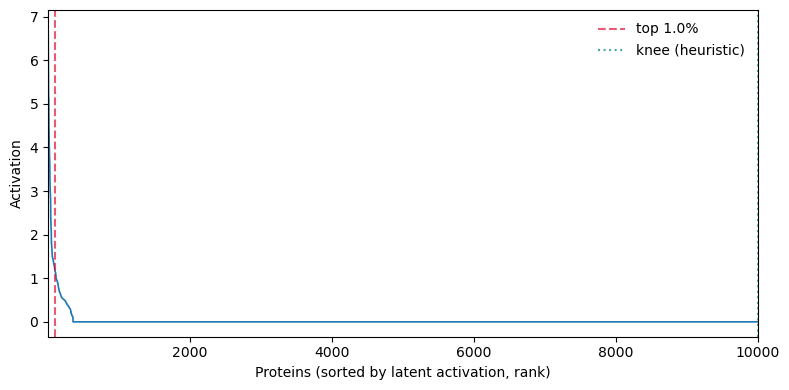

In [ ]:
latent_specs = [
    (12, 2112),
    (8, 2677),
    (12, 3035),
    (8, 488),
    (12, 1256),
    (12, 3794),
    (12, 3536),
    (12, 2797),
    (16, 1166),
    (8, 2775),
    (8, 2166),
    (12, 2472),
    (12, 1082),
    # add more (layer_i, latent_ind) tuples here
]

import numpy as np
import matplotlib.pyplot as plt
layer_i = 8
latent_ind = 488
flattened_id = to_flattened_id(int(layer_i), int(latent_ind))
latent_i = subset_list.index(flattened_id)
# 1) Grab activations for the latent (length N)
v = to_numpy(all_acts)[:, latent_i].astype(float)

# 2) Sort descending
order = np.argsort(v)[::-1]
s = v[order]
N = s.size

# 3) Optional: mark the "top (1 - tau)" fraction (e.g., top 1%)
tau = 0.99
k_top = max(1, int(np.ceil((1 - tau) * N)))

# 4) Simple knee heuristic: max deviation from straight line between endpoints
x = np.linspace(0.0, 1.0, N)
y = (s - s.min()) / (s.max() - s.min() + 1e-12)
line = 1.0 - x
knee_idx = int(np.argmax(y - line))

# 5) Plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(1, N + 1), s, lw=1.2)
ax.axvline(k_top, color="crimson", ls="--", alpha=0.7, label=f"top {100*(1-tau):.1f}%")
ax.axvline(knee_idx + 1, color="teal", ls=":", alpha=0.7, label="knee (heuristic)")
ax.set_xlabel("Proteins (sorted by latent activation, rank)")
ax.set_ylabel("Activation")
ax.set_xlim(1, N)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

In [30]:
!pwd

/work/pi_jensen_umass_edu/jnainani_umass_edu/plm_circuits/notebooks/domain_corr


In [38]:
import os
import pandas as pd

def run_domain_enrichment_for_latents(
    all_acts,
    all_properties,
    latent_specs,  # list of (layer_i, latent_ind)
    domain_indices=None,
    tau=0.98,
    n_in_min=10,
    n_out_min=200,
    use_bonferroni=True,
    return_tau_all_in=True,
    coverage_fracs=(0.95, 0.90),
    p_adj_thresh=0.05,
    or_thresh=5.0,
    out_hits_csv="/work/pi_jensen_umass_edu/jnainani_umass_edu/plm_circuits/notebooks/domain_corr/domain_hits.csv",
    out_full_csv=None,   # e.g., "/work/.../domain_results_all.csv"
    max_hits_per_latent=None,  # e.g., 25 to cap rows per latent; None for all
):
    all_full = []
    all_hits = []

    for layer_i, latent_ind in latent_specs:
        flattened_id = to_flattened_id(int(layer_i), int(latent_ind))
        if flattened_id not in subset_list:
            print(f"Skipping L{layer_i}-{latent_ind} (flattened {flattened_id}) not in subset_list")
            continue
        latent_i = subset_list.index(flattened_id)

        df = screen_domains_tail_enrichment(
            all_acts=all_acts,
            all_properties=all_properties,
            latent_i=latent_i,
            domain_indices=domain_indices,
            tau=float(tau),
            n_in_min=int(n_in_min),
            n_out_min=int(n_out_min),
            use_bonferroni=bool(use_bonferroni),
            return_tau_all_in=bool(return_tau_all_in),
            coverage_fracs=coverage_fracs,
        )

        df["layer_i"] = int(layer_i)
        df["latent_ind"] = int(latent_ind)
        df["flattened_id"] = int(flattened_id)
        df["latent_i"] = int(latent_i)
        df["latent_label"] = f"L{layer_i}-{latent_ind}"
        df["tau_input"] = float(tau)

        all_full.append(df)

        hits = df[(df["p_adj"] <= p_adj_thresh) & (df["odds_ratio"] >= or_thresh)].copy()
        if max_hits_per_latent is not None:
            hits = hits.head(int(max_hits_per_latent))
        all_hits.append(hits)

    full_df = pd.concat(all_full, ignore_index=True) if all_full else pd.DataFrame()
    hits_df = pd.concat(all_hits, ignore_index=True) if all_hits else pd.DataFrame()

    if out_hits_csv:
        os.makedirs(os.path.dirname(out_hits_csv), exist_ok=True)
        hits_df.to_csv(out_hits_csv, index=False)
        print(f"Saved hits to: {out_hits_csv}")
    if out_full_csv:
        os.makedirs(os.path.dirname(out_full_csv), exist_ok=True)
        full_df.to_csv(out_full_csv, index=False)
        print(f"Saved full results to: {out_full_csv}")

    return hits_df, full_df

In [40]:
latent_specs = [
    (12, 2112),
    (8, 2677),
    (12, 3035),
    (8, 488),
    (12, 1256),
    (12, 3794),
    (12, 3536),
    (12, 2797),
    (16, 1166),
    (8, 2775),
    (8, 2166),
    (12, 2472),
    (12, 1082),
    # add more (layer_i, latent_ind) tuples here
]

hits_df, full_df = run_domain_enrichment_for_latents(
    all_acts=all_acts,
    all_properties=all_properties,
    latent_specs=latent_specs,
    domain_indices=None,  # or a subset
    tau=0.98,
    n_in_min=10,
    n_out_min=200,
    use_bonferroni=True,
    return_tau_all_in=True,
    coverage_fracs=(0.95, 0.90),
    p_adj_thresh=0.05,
    or_thresh=5.0,
    out_hits_csv="/work/pi_jensen_umass_edu/jnainani_umass_edu/plm_circuits/results/domain_correlation_results/tail_enrich/domain_hits.csv",
    out_full_csv="/work/pi_jensen_umass_edu/jnainani_umass_edu/plm_circuits/results/domain_correlation_results/tail_enrich/domain_results_all.csv",
    max_hits_per_latent=None,  # or 25 to mimic head(25)
)

hits_df.head()

Saved hits to: /work/pi_jensen_umass_edu/jnainani_umass_edu/plm_circuits/results/domain_correlation_results/tail_enrich/domain_hits.csv
Saved full results to: /work/pi_jensen_umass_edu/jnainani_umass_edu/plm_circuits/results/domain_correlation_results/tail_enrich/domain_results_all.csv


,domain_idx,domain_name,n_in,n_out,a_top_in,b_top_out,c_not_top_in,d_not_top_out,odds_ratio,fisher_p,...,median_pos_percentile,tau_cover_95,tau_cover_90,tau_all_in,layer_i,latent_ind,flattened_id,latent_i,latent_label,tau_input
0,9059,Alpha/Beta hydrolase fold,63,9937,63,137,0,9800,9052.098182,1.913355e-112,...,0.996900,0.994099,0.994399,0.993799,12,2112,10304,80,L12-2112,0.98
1,3924,Adenylate kinase/UMP-CMP kinase,20,9980,20,180,0,9800,2226.152355,4.001052e-35,...,0.989049,0.983198,0.984698,0.982198,12,2112,10304,80,L12-2112,0.98
2,617,"Adenylate kinase, conserved site",19,9981,19,181,0,9800,2105.892562,2.206326e-33,...,0.989099,0.983098,0.984498,0.982198,12,2112,10304,80,L12-2112,0.98
3,2514,Amidase signature domain,17,9983,17,183,0,9800,1869.305177,6.601245e-30,...,0.991399,0.990599,0.990699,0.990599,12,2112,10304,80,L12-2112,0.98
4,3746,Amidase,17,9983,17,183,0,9800,1869.305177,6.601245e-30,...,0.991399,0.990599,0.990699,0.990599,12,2112,10304,80,L12-2112,0.98


In [68]:
layer_i = 8
latent_ind = 488
flattened_id = to_flattened_id(int(layer_i), int(latent_ind))
latent_i = subset_list.index(flattened_id)

df_hits = screen_domains_tail_enrichment(
    all_acts=all_acts,
    all_properties=all_properties,
    latent_i=latent_i,                # e.g., 56 for your L8-2677 in subset_list
    domain_indices=None,
    tau=0.99,                         # top 1%
    n_in_min=10,
    n_out_min=200,
    use_bonferroni=True
)
# df_hits.head(25)
hits = df_hits[(df_hits["p_adj"] <= 0.05) & (df_hits["odds_ratio"] >= 5)]
hits.head(25)

,domain_idx,domain_name,n_in,n_out,a_top_in,b_top_out,c_not_top_in,d_not_top_out,odds_ratio,fisher_p,p_adj,median_pos_percentile
0,9059,Alpha/Beta hydrolase fold,63,9937,43,57,20,9880,372.666667,3.038954e-75,3.671057e-72,0.996900
1,659,Alpha/beta hydrolase fold-1,16,9984,15,85,1,9899,1746.882353,5.313775e-30,6.419040e-27,0.998000
2,4162,Small GTPase,16,9984,9,91,7,9893,139.775510,7.481568e-15,9.037734e-12,0.990549
3,1395,Small GTP-binding domain,128,9872,14,86,114,9786,13.974296,2.686131e-11,3.244847e-08,0.482498
4,4213,Phosphopantetheine adenylyltransferase,18,9982,6,94,12,9888,52.595745,1.448054e-08,1.749249e-05,0.482498
5,1344,Cytidyltransferase-like domain,37,9963,6,94,31,9869,20.320522,1.555329e-06,1.878837e-03,0.482498


In [64]:
hits = df_hits[(df_hits["p_adj"] <= 0.05) & (df_hits["odds_ratio"] >= 5)]
hits.head(25)

,domain_idx,domain_name,n_in,n_out,a_top_in,b_top_out,c_not_top_in,d_not_top_out,odds_ratio,fisher_p,p_adj,median_pos_percentile
0,8787,WD40/YVTN repeat-like-containing domain superf...,57,9943,52,48,5,9895,2143.916667,3.510663e-105,4.240881e-102,0.997100
1,10047,WD40 repeat,43,9957,43,57,0,9900,14979.886957,2.520766e-91,3.045085e-88,0.997900
2,9289,WD40-repeat-containing domain superfamily,42,9958,42,58,0,9900,14385.341880,4.327894e-89,5.228096e-86,0.997850
3,448,"WD40 repeat, conserved site",27,9973,27,73,0,9900,7408.537415,2.162430e-56,2.612216e-53,0.998700
4,10082,"PAC1/LIS1-like, WD-40 repeat",22,9978,22,78,0,9900,5675.445860,8.433977e-46,1.018824e-42,0.998750
5,1547,YqgF/RNase H-like domain,13,9987,8,92,5,9895,172.086957,9.293704e-14,1.122679e-10,0.990399
6,4874,Putative pre-16S rRNA nuclease,13,9987,8,92,5,9895,172.086957,9.293704e-14,1.122679e-10,0.990399
7,9631,YqgF/RNase H-like domain superfamily,13,9987,8,92,5,9895,172.086957,9.293704e-14,1.122679e-10,0.990399
8,8705,Ribonuclease H-like superfamily,68,9932,8,92,60,9840,14.260870,3.397664e-07,4.104379e-04,0.585884


In [ ]:
12:2112, 9059

In [32]:
i = latent_i
for j in relevant_interpro_entries_indices:
    tmp_x = all_acts[all_properties[:,j] != 0,i]
    tmp_y = all_acts[all_properties[:,j] == 0,i]
    latents_property_pvals[latent_i,j] = mannwhitneyu(tmp_x, tmp_y, alternative="greater").pvalue
    latents_property_statistic[i,j] = mannwhitneyu(tmp_x, tmp_y, alternative="greater").statistic
    latents_property_effect_size[i,j,0] = tmp_x.mean()
    latents_property_effect_size[i,j,1] = tmp_y.mean()
    latents_property_effect_size[i,j,2] = all_acts[:,0].std()
    latents_property_effect_size[i,j,3] = (tmp_x.mean() - tmp_y.mean())/(all_acts[:,0].std())
    print(f"  p-value: {latents_property_pvals[i,j]:.3e}")
    print(f"  Mann-Whitney U statistic: {latents_property_statistic[i,j]:.1f}")
    print(f"  Mean for positive class: {latents_property_effect_size[i,j,0]:.3f}")
    print(f"  Mean for negative class: {latents_property_effect_size[i,j,1]:.3f}")
    print(f"  Standard deviation: {latents_property_effect_size[i,j,2]:.3f}")
    print(f"  Effect size (Cohen's d): {latents_property_effect_size[i,j,3]:.3f}")

  p-value: 6.987e-13
  Mann-Whitney U statistic: 169079.5
  Mean for positive class: 11.592
  Mean for negative class: 1.966
  Standard deviation: 0.866
  Effect size (Cohen's d): 11.114
  p-value: 1.270e-11
  Mann-Whitney U statistic: 156818.5
  Mean for positive class: 9.378
  Mean for negative class: 1.971
  Standard deviation: 0.866
  Effect size (Cohen's d): 8.553
  p-value: 2.966e-12
  Mann-Whitney U statistic: 174015.5
  Mean for positive class: 8.139
  Mean for negative class: 1.972
  Standard deviation: 0.866
  Effect size (Cohen's d): 7.121
  p-value: 3.107e-15
  Mann-Whitney U statistic: 237090.5
  Mean for positive class: 7.093
  Mean for negative class: 1.970
  Standard deviation: 0.866
  Effect size (Cohen's d): 5.915
  p-value: 1.383e-13
  Mann-Whitney U statistic: 186629.0
  Mean for positive class: 9.853
  Mean for negative class: 1.968
  Standard deviation: 0.866
  Effect size (Cohen's d): 9.105
  p-value: 3.107e-15
  Mann-Whitney U statistic: 237090.5
  Mean for posi

In [65]:
import numpy as np
from scipy.stats import mannwhitneyu

try:
    import torch
except Exception:
    torch = None

def to_numpy_1d(a):
    # Convert numpy/torch/list to 1D numpy and drop NaNs/Infs
    if torch is not None and isinstance(a, torch.Tensor):
        a = a.detach().cpu().numpy()
    else:
        a = np.asarray(a)
    a = np.ravel(a)
    if a.size == 0:
        return a
    mask = np.isfinite(a)
    return a[mask]

i = latent_i  # latent index
# for i in tqdm(range(latents_property_pvals.shape[0])):
for j in test_j[:1]:
    # Define classes:
    # x = "positives" where property != 0
    # y = "negatives" where property == 0
    # If your gold standard uses the opposite, AUROC < 0.5 will reveal it.
    x_raw = all_acts[all_properties[:, j] != 0, i]
    y_raw = all_acts[all_properties[:, j] == 0, i]

    x = to_numpy_1d(x_raw)
    y = to_numpy_1d(y_raw)

    n_pos, n_neg = x.size, y.size
    if n_pos == 0 or n_neg == 0:
        print(f"Property j={j}: one of the groups is empty (n_pos={n_pos}, n_neg={n_neg}); skipping.\n")
        continue

    # Mann–Whitney U tests
    res_greater = mannwhitneyu(x, y, alternative="greater")
    res_two = mannwhitneyu(x, y, alternative="two-sided")

    U = float(res_greater.statistic)
    auc = U / (n_pos * n_neg)  # AUROC = P(X > Y) + 0.5 * P(X == Y) under mid-ranks

    mean_pos = float(np.mean(x))
    mean_neg = float(np.mean(y))

    if n_pos + n_neg > 2:
        pooled_std = float(np.std(np.concatenate([x, y]), ddof=1))
    else:
        pooled_std = np.nan

    cohens_d = (mean_pos - mean_neg) / pooled_std if np.isfinite(pooled_std) and pooled_std > 0 else np.nan

    if auc < 0.2:
        print(f"  AUROC < 0.2; swapping classes would give AUROC={1-auc:.3f}")
    if auc > 0.95:
        cur_lat_id = subset_list[i]  # not subset_list[latent_i]
        layer_id = ((cur_lat_id // 4096) + 1) * 4
        lat_id = int(cur_lat_id % 4096)
        print(f"  AUROC > 0.8; latent {i} is in layer {layer_id} with latent ID {lat_id}")
        print(f"Property latent={i}, j={j}")
        print(f"  n_pos={n_pos}, n_neg={n_neg}")
        print(f"  Mean(pos)={mean_pos:.3f}, Mean(neg)={mean_neg:.3f}")
        if np.isfinite(pooled_std):
            print(f"  Pooled std={pooled_std:.3f}, Cohen's d={cohens_d:.3f}")
        else:
            print("  Pooled std=nan, Cohen's d=nan")
        print(f"  Mann-Whitney U={U:.1f}")
        print(f"  p-value (greater)={res_greater.pvalue:.3e}")
        print(f"  p-value (two-sided)={res_two.pvalue:.3e}")
        print(f"  AUROC={auc:.3f}")
    # print()

  AUROC > 0.8; latent 80 is in layer 12 with latent ID 2112
Property latent=80, j=9059
  n_pos=63, n_neg=9937
  Mean(pos)=11.973, Mean(neg)=0.204
  Pooled std=1.090, Cohen's d=10.797
  Mann-Whitney U=626031.0
  p-value (greater)=8.754e-85
  p-value (two-sided)=1.751e-84
  AUROC=1.000


In [ ]:
for i in tqdm(range(latents_property_pvals.shape[0])):
    for j in range(latents_property_pvals.shape[1]):
        tmp_x = all_acts[all_properties[:,j] != 0,i]
        tmp_y = all_acts[all_properties[:,j] == 0,i]
        latents_property_pvals[i,j] = mannwhitneyu(tmp_x, tmp_y, alternative="greater").pvalue
        latents_property_statistic[i,j] = mannwhitneyu(tmp_x, tmp_y, alternative="greater").statistic
        latents_property_effect_size[i,j,0] = tmp_x.mean()
        latents_property_effect_size[i,j,1] = tmp_y.mean()
        latents_property_effect_size[i,j,2] = all_acts[:,0].std()
        latents_property_effect_size[i,j,3] = (tmp_x.mean() - tmp_y.mean())/(all_acts[:,0].std())